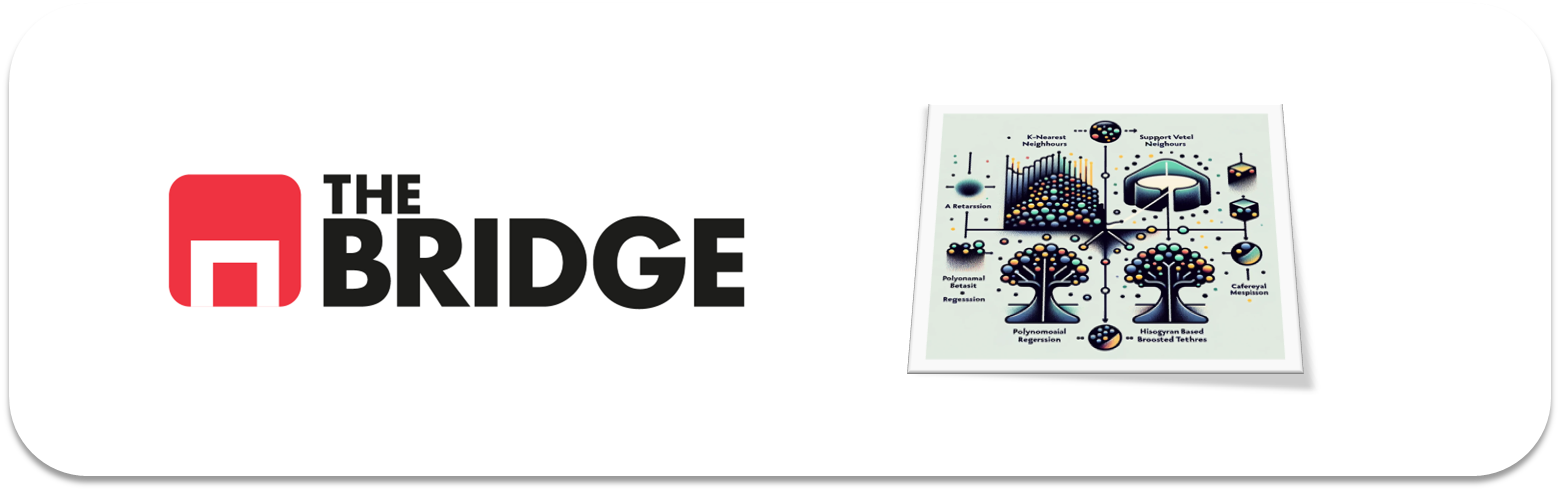

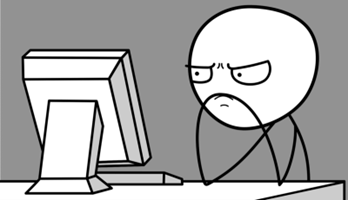

Para hacer un **repaso a los problemas de regresión con ML**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### INTRODUCCIóN: PROCESO DE ML

En los siguientes ejercicios vamos a seguir (de nuevo) los pasos básicos en la creación de un modelo de ML para resolver un problema de predicción a partir de un dataset que incluye el target, es decir, un aprendizaje supervisado.

En concreto, vamos a trabajar sobre un problema de clasificación a través de los siguientes pasos:

1. Entendimiento del problema (selección de la métrica más adecuada)  
2. Obtención de datos y primer contacto  
3. Train y Test  
4. MiniEDA: Análisis del target, análisis bivariante, entendimiento de las features, selección de las mismas (si es necesario)  
5. Preparación del dataset de Train: Conversión de categóricas, tratamiento de numéricas  
6. Selección e instanciación de modelos. Baseline.
7. Comparación de modelos (lo haremos por comparación con validación, puedes hacerlo por comparación de modelos de hiperparámetros optimizados, si así lo prefieres)  
8. Selección de modelo: Optimización de hiperparámetros (ten en cuenta la nota de 7)  
9. Evaluación contra test.  
10. Análisis de errores, posibles acciones futuras.  
11. EXTRA: Persistencia del modelo en disco.  

### El problema de Negocio

El ayuntamiento de Freehold, Nueva Jersey, está preocupado por los niveles de Ozono en situaciones de contaminación. Ha adquirido unos sensores muy potentes que permiten medir la composición de la calidad del aire casi en tiempo real, pero desgraciadamente la medida de Ozono se obtiene mucho más tarde (casi 12 horas después, este dato de las horas no es relevante para el problema). Las medidas son enviadas a una plataforma central donde se quiere incorporar un modelo que en función de esas medidas pueda predecir el nivel de $O_3$ (Ozono) en el aire y establecer alarmas y umbrales para avisar a la población o tomar medidas si es necesaria.

El concejal de urbanismo y tecnología, Bruce S., os contrata para que creéis ese modelo y para ello os suministra un dataset con medidas de la calidad de aire donde han incorporado el nivel de Ozono ("PT08.S5(O3)") posteriormente. Quieren un modelo que se equivoque en media en menos de 100 unidades por millón (la medida en la que tienen registrada la presencia de Ozono).

¡Manos a la obra!

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [15]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import (
    mean_squared_error, root_mean_squared_error,
    mean_absolute_error, r2_score
)

from toolbox_ml.eda.core import (
    describe_df, tipifica_variables, 
    get_features_num_regression, 
    plot_features_num_regression, 
    get_features_cat_regression, 
    plot_features_cat_regression
)



# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100



### Ejercicio 1: Entendiendo el problema de "Negocio"

En función de la descripción del problema de "negocio" y sin mirar todavía los datos, ¿qué métricas creess más conveniente para medir el rendimiento del modelo a construir y, por tanto, para comparar posibles modelos entre sí?

Como lo que pide le cliente es que el modelo no se equivoque de media en menos de 100 unidaddes la métrica que voy a utilizar es MAE (Mean Absolute Error)  
y como métrica secundaria R^2, para entender que proporcion de la varianza del O3 explica el modelo.

### Ejercicio 2: Obtención y primer "vistazo"

Carga el dataset, muestra sus primeras filas, su descripción general y determina el tipo de variables que vamos a manejar. Escoge el target y crea una variable `target` y asignalé el nombre de la columna correspondiente.

In [2]:
df = pd.read_csv("./data/air_contamination.csv")
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [3]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
CO(GT),float64,0.0,95,1.06
PT08.S1(CO),float64,0.0,3245,36.09
NMHC(GT),int64,0.0,428,4.76
C6H6(GT),float64,0.0,3772,41.95
PT08.S2(NMHC),float64,0.0,3772,41.95
NOx(GT),float64,0.0,2362,26.27
PT08.S3(NOx),float64,0.0,3518,39.13
NO2(GT),float64,0.0,1367,15.2
PT08.S4(NO2),float64,0.0,4407,49.02
PT08.S5(O3),float64,0.0,4678,52.03


In [4]:
tipifica_variables(df, umbral_categoria=10, umbral_continua=15)

,nombre_variable,tipo_sugerido
0,CO(GT),Numérica Discreta
1,PT08.S1(CO),Numérica Continua
2,NMHC(GT),Numérica Discreta
3,C6H6(GT),Numérica Continua
4,PT08.S2(NMHC),Numérica Continua
5,NOx(GT),Numérica Continua
6,PT08.S3(NOx),Numérica Continua
7,NO2(GT),Numérica Continua
8,PT08.S4(NO2),Numérica Continua
9,PT08.S5(O3),Numérica Continua


In [5]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,-34.897053,1099.707856,-158.702591,10.082993,939.029205,163.732788,835.370973,56.654087,1456.143486,1022.780725,18.316054,49.232360,1.025530
std,78.202259,217.084571,140.680200,7.449640,266.829000,252.081877,256.815106,126.902274,346.204540,398.480897,8.832888,17.316389,0.403813
min,-200.000000,647.250000,-200.000000,0.149048,383.250000,-200.000000,322.000000,-200.000000,551.000000,221.000000,-1.900000,9.175000,0.184679
25%,0.600000,936.750000,-200.000000,4.436942,734.375000,49.000000,657.875000,52.000000,1226.625000,731.375000,11.787500,35.812500,0.736769
50%,1.500000,1063.000000,-200.000000,8.239851,909.000000,139.800000,805.500000,96.000000,1462.750000,963.250000,17.750000,49.550000,0.995395
75%,2.600000,1231.250000,-200.000000,13.988478,1116.250000,280.000000,969.250000,132.000000,1673.500000,1273.375000,24.400000,62.500001,1.313701
max,11.900000,2039.750000,1189.000000,63.741476,2214.000000,1479.000000,2682.750000,332.600000,2775.000000,2522.750000,44.600000,88.725000,2.231036


In [6]:
target ="PT08.S5(O3)"

print(f"Valores únicos en price: {df[target].nunique()}")
print(f"Rango: {df[target].min():.0f} — {df[target].max():.0f}")
print(f"Media: {df[target].mean():.0f}  |  Mediana: {df[target].median():.0f}")

Valores únicos en price: 4678
Rango: 221 — 2523
Media: 1023  |  Mediana: 963


### Ejercicio 3: Split

Haz el split en train y test.

In [7]:
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("\nTest:", X_test.shape)

Train: (7192, 12)

Test: (1799, 12)


### Ejercicio 4: MiniEDA (I)

Analiza la distribución del target brevemente.

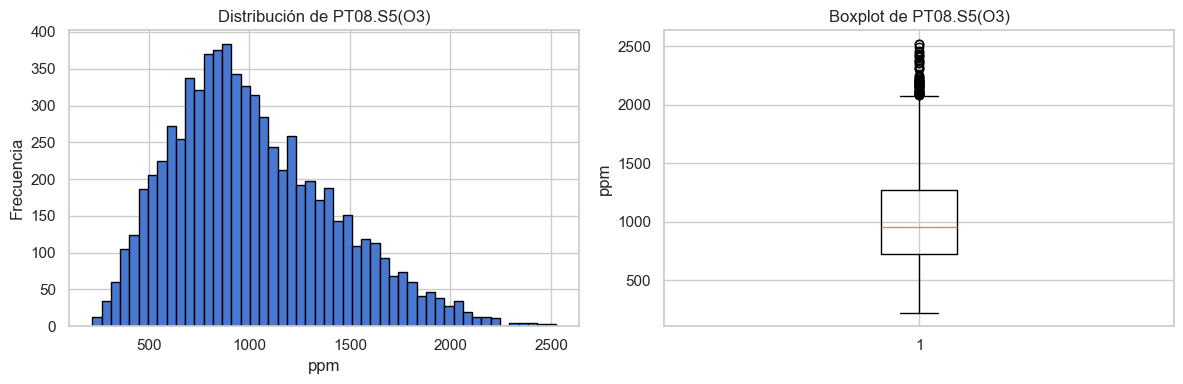

count    7192.000000
mean     1017.120643
std       397.817754
min       221.000000
25%       725.187500
50%       954.375000
75%      1268.062500
max      2522.250000
Name: PT08.S5(O3), dtype: float64
Skewness: 0.628


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(y_train, bins=50, edgecolor='black')
axes[0].set_title('Distribución de PT08.S5(O3)')
axes[0].set_xlabel('ppm')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(y_train, vert=True)
axes[1].set_title('Boxplot de PT08.S5(O3)')
axes[1].set_ylabel('ppm')

plt.tight_layout()
plt.show()

print(y_train.describe())
print(f"Skewness: {y_train.skew():.3f}")

### Ejercicio 5: MiniEDA (II)

Analiza bivariantemente las variables contra el target, para las numéricas analiza la correlación numéricamente y gráficamente, para las categóricas analiza la distribución del target para cada valor de la categórica.

PT08.S1(CO)      0.901005
PT08.S2(NMHC)    0.879959
C6H6(GT)         0.864269
NOx(GT)          0.623100
PT08.S4(NO2)     0.590688
NO2(GT)          0.337581
RH               0.133955
CO(GT)           0.128110
NMHC(GT)         0.110077
AH               0.069113
T               -0.032899
PT08.S3(NOx)    -0.794185
Name: PT08.S5(O3), dtype: float64


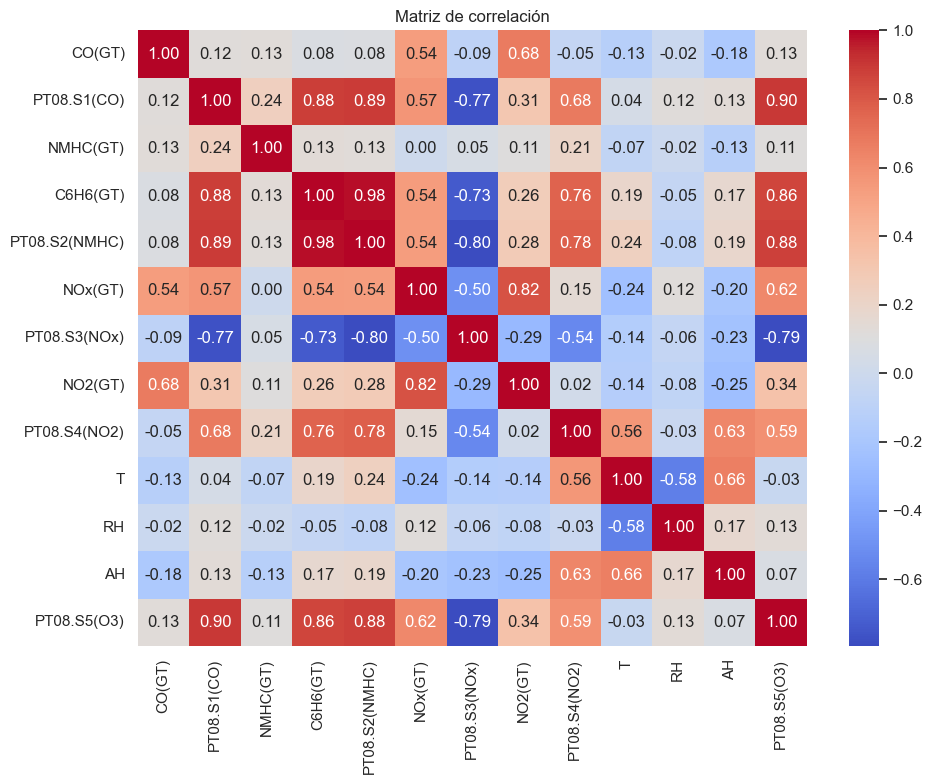

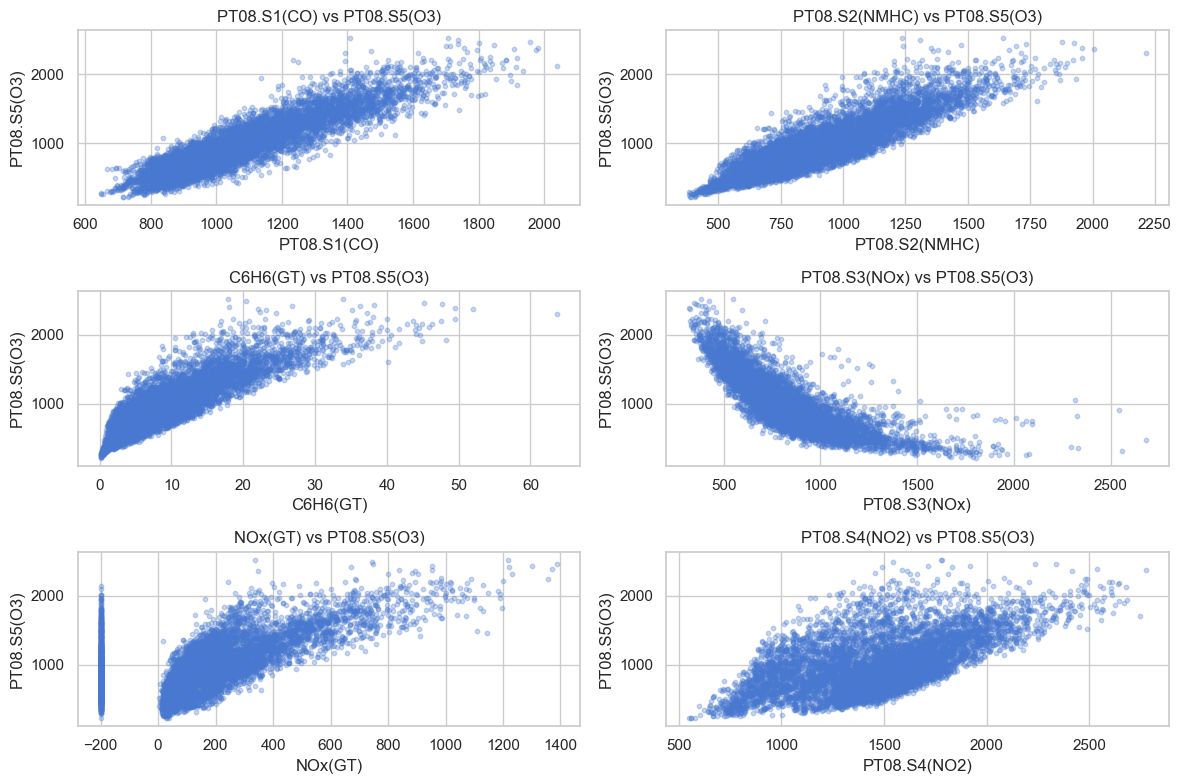

In [9]:
# Correlaciones numéricas
corr = X_train.join(y_train).corr()[target].drop(target).sort_values(ascending=False)
print(corr)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(X_train.join(y_train).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

# Scatterplots de las features más correlacionadas
top_features = corr.abs().sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), top_features):
    ax.scatter(X_train[col], y_train, alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.set_title(f'{col} vs {target}')
plt.tight_layout()
plt.show()

In [10]:
features_corr= get_features_num_regression(df,target_col=target, umbral_corr=0.5)
features_corr

['PT08.S1(CO)',
 'C6H6(GT)',
 'PT08.S2(NMHC)',
 'NOx(GT)',
 'PT08.S3(NOx)',
 'PT08.S4(NO2)']

In [11]:
plot_features_num_regression(df)

Error: '' no existe en el DataFrame.


In [12]:
cols_con_negativos = [col for col in X_train.columns if (X_train[col] == -200).any()]
print(cols_con_negativos)

for col in cols_con_negativos:
    total = len(X_train)
    n_negativos = (X_train[col] == -200).sum()
    print(f"{col}: {n_negativos} valores -200 ({n_negativos/total*100:.1f}%)")

['CO(GT)', 'NMHC(GT)', 'NOx(GT)', 'NO2(GT)']
CO(GT): 1335 valores -200 (18.6%)
NMHC(GT): 6505 valores -200 (90.4%)
NOx(GT): 1283 valores -200 (17.8%)
NO2(GT): 1286 valores -200 (17.9%)


### Ejercicio 6: MiniEDA (III)

Crea una variable de tipo lista a la que asignes los valores de las columnas que creas conveniente emplear como features en función de lo visto en el miniEDA. Haz una lista de modelos/algoritmos que vas a emplear para hacer el modelo (solo los nombres). En función de la lista anterior, ¿tienes que tratar las variables, por qué?

In [13]:
features = [
    'PT08.S1(CO)',
    'PT08.S2(NMHC)',
    'C6H6(GT)',
    'PT08.S3(NOx)',
    'PT08.S4(NO2)',
    'CO(GT)',      # imputar -200
    'NOx(GT)',     # imputar -200
    'NO2(GT)',     # imputar -200
    'T',
    'RH',
    'AH'
]

Modelos escogidos:
* Ridge Regression
* Random Forest
* Gradient Boosting
* LGBMRegressor
* CatBoostRegressor

### Ejercicio 7: Tratamiento de features

Trata las features de manera que puedan ser empleadas por los modelos que escogite en el ejercicio anterior. Recuerda que este es un paso necesario porque los modelos no entienden de primeras de "letras" (salvo alguno que no es que entienda sino que hace sus transformaciones por dentro) y porque en determinados algoritmos es necesario que los rangos de las features estén escalados para que el algoritmo no se decante (érroneamente) por alguna feature sólo porque sus valores son mayores en rango que el de otras. NOTA: Recuerda que lo que le hagas al train, se lo tienes que hacer al test

In [14]:
cols_impute = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']

# 1. Reemplazar -200 por NaN en todos
X_train_features = X_train[features].copy()
X_test_features  = X_test[features].copy()

X_train_features.replace(-200, np.nan, inplace=True)
X_test_features.replace(-200, np.nan, inplace=True)

# 2. Imputar con mediana usando fillna (mediana calculada solo en train)
medians = X_train_features[cols_impute].median()

X_train_features[cols_impute] = X_train_features[cols_impute].fillna(medians)
X_test_features[cols_impute]  = X_test_features[cols_impute].fillna(medians)

# 3. Escalado solo para Ridge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled  = scaler.transform(X_test_features)

### Ejercicio 8: Creación de los dataset de train y test

Crea las parejas X,y de train y test.

### Ejercicios 9:

Importa e instancia los modelos que hayas escogido en el ejercicio 6. En general, no hace falta que asignes ahora ningún hiperparámetro salvo en los basados en árboles en los que debes escoger un max_depth para evitar el sobreajuste inicial. 

In [19]:
ridge    = Ridge()
rf       = RandomForestRegressor(random_state=42)
gb       = GradientBoostingRegressor(random_state=42)
lgbm     = LGBMRegressor(random_state=42)
catboost = CatBoostRegressor(random_state=42, verbose=0)


### Ejercicio 10: Comparativa de modelos

Haz la comparativa de modelos empleando cross_val_score (es decir la validación cruzada). Utiliza k = 5, y un scoring acorde a la métrica escogida en el ejercicio 1. Si no tienes clara la métrica entonces emplea "mean_absolute_error" (recuerda el funcionamiento del scoring en "sklearn", no te valdrá poner "mean_absolute_error"). Escoge el modelo ganador.

In [20]:
modelos = {
    "Ridge": (ridge, X_train_scaled),
    "RandomForest": (rf, X_train_features),
    "GradBoost": (gb, X_train_features),
    "LGBM": (lgbm, X_train_features),
    "CatBoost": (catboost, X_train_features)
}

for nombre, (modelo, X) in modelos.items():
    scores = cross_validate(modelo, X, y_train, cv=5,
                            scoring=['neg_mean_absolute_error', 'r2'])
    mae = -scores['test_neg_mean_absolute_error'].mean()
    r2  = scores['test_r2'].mean()
    print(f"{nombre}: MAE = {mae:.2f} | R2 = {r2:.3f}")

Ridge: MAE = 104.76 | R2 = 0.885
RandomForest: MAE = 78.90 | R2 = 0.928
GradBoost: MAE = 88.75 | R2 = 0.912
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,000201 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2629
[LightGBM] [Info] Number of data points in the train set: 5753, number of used features: 11
[LightGBM] [Info] Start training from score 1019,094516
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,000236 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2631
[LightGBM] [Info] Number of data points in the train set: 5753, number of used features: 11
[LightGBM] [Info] Start training from score 1016,015890
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,000253 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2629
[LightGB

### Ejercicio 11: Ajuste de hiperparámetros

Escoge un grid para ajustar los hiperparámetros de tu modelo. Crea un objeto GridSearch y "ajustalo" (emplea su método fit) para encontrar la mejor combinaciónde hiperparámetros empleando la métrica que decidimos en el ejercio 1. Si no lo tienes claro emplea "mean absolute error". 

In [21]:
param_grid ={
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "iterations": [100, 300, 500]
}

grid_search = GridSearchCV (
    estimator = catboost,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train_features, y_train)

print("Mejores hiperparametros:", grid_search.best_params_)
print(f"Mejor MAE CV: {-grid_search.best_score_:.3f}")

Mejores hiperparametros: {'depth': 8, 'iterations': 500, 'learning_rate': 0.1}
Mejor MAE CV: 74.099


### Ejercicio 12: Evaluación del modelo

Evalúa el modelo contra el dataset de test. Muestra el informe de clasificación y haz una valoración de si el hospital aceptaría el modelo o no.

In [22]:
mejor_modelo = grid_search.best_estimator_

y_pred = mejor_modelo.predict(X_test_features)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2:", r2)

MAE: 72.1341203903143
R2: 0.935471377895608


### Ejercicio 13: Análisis de errores

Comparar los valores predichos contra los reales mediante una gráfica (puedes emplear la función que empleamos en el workout de la unidad anterior). Haz un pequeño análisis.

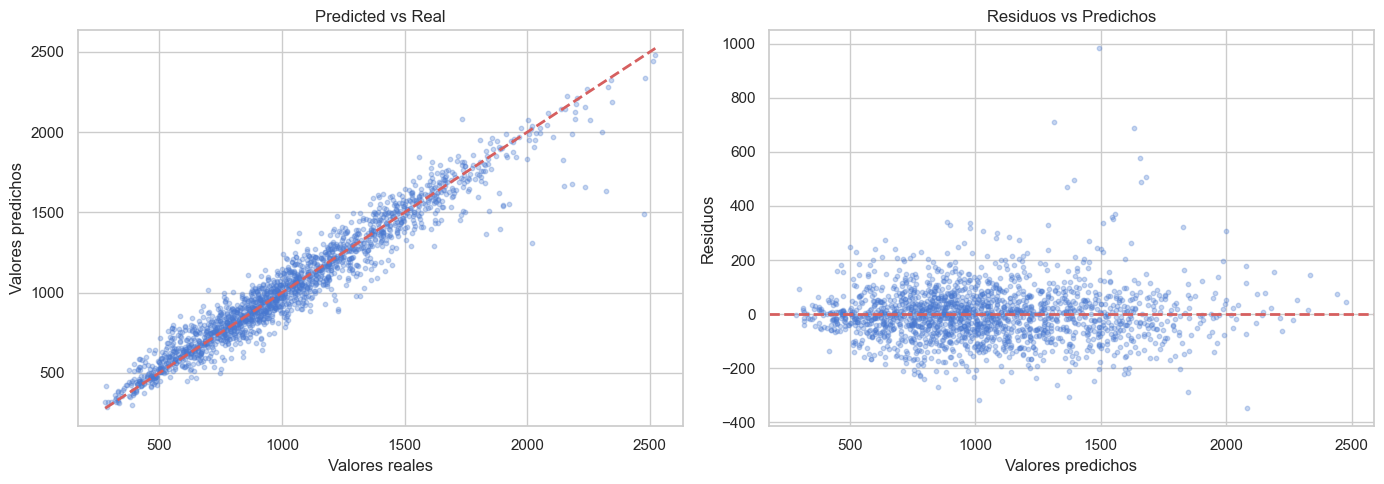

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Real
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Valores reales')
axes[0].set_ylabel('Valores predichos')
axes[0].set_title('Predicted vs Real')

# Residuos
residuos = y_test - y_pred
axes[1].scatter(y_pred, residuos, alpha=0.3, s=10)
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Valores predichos')
axes[1].set_ylabel('Residuos')
axes[1].set_title('Residuos vs Predichos')

plt.tight_layout()
plt.show()

### EXTRA: 

Busca en Internet o pregúntale a tu AI preferida, cómo se graba un modelo en disco y gúardalo en "./models/o3_pred" con la extesión apropiada.

In [24]:
import os

os.makedirs("·/models", exist_ok=True)

mejor_modelo.save_model("·/models/o3_pred.cbm")

print("Modelo guardado correctamente")

Modelo guardado correctamente
